In [2]:
# Predicting Start_Tech_Oscar
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Hyperopt
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

In [3]:
# Load Data
df = pd.read_csv('/Users/rafael/Desktop/archive/Movie_classification.csv')
print("Data shape:", df.shape)
df.head() 

Data shape: (506, 19)


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1


In [4]:
# Feature Engineering
# Check for missing values
print(df.isnull().sum())

# Fill missing values: e.g. Time_taken might have nulls
df['Time_taken'] = df['Time_taken'].fillna(df['Time_taken'].mean())

# Target Variable
y = df['Start_Tech_Oscar']

# Features
X = df.drop('Start_Tech_Oscar', axis=1)

# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

Marketing expense       0
Production expense      0
Multiplex coverage      0
Budget                  0
Movie_length            0
Lead_ Actor_Rating      0
Lead_Actress_rating     0
Director_rating         0
Producer_rating         0
Critic_rating           0
Trailer_views           0
3D_available            0
Time_taken             12
Twitter_hastags         0
Genre                   0
Avg_age_actors          0
Num_multiplex           0
Collection              0
Start_Tech_Oscar        0
dtype: int64


In [5]:
# Hyperparameter Optimization Spaces

# Random Forest Space
rf_space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
    'max_depth': hp.quniform('max_depth', 3, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 20, 1)
}

# LightGBM Space
lgb_space = {
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_samples': hp.quniform('min_child_samples', 10, 50, 1)
}

# XGBoost Space
xgb_space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 10),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0)
} 

In [6]:
# Hyperopt Objective Functions

def rf_objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(**params, random_state=42, n_jobs=-1))
    ])
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return {'loss': -score, 'status': STATUS_OK}

def lgb_objective(params):
    clf_params = {
        'num_leaves': int(params['num_leaves']),
        'learning_rate': params['learning_rate'],
        'colsample_bytree': params['colsample_bytree'],
        'subsample': params['subsample'],
        'max_depth': int(params['max_depth']),
        'min_child_samples': int(params['min_child_samples'])
    }
    
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', LGBMClassifier(**clf_params, random_state=42, n_estimators=100, verbose=-1))
    ])
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return {'loss': -score, 'status': STATUS_OK}

def xgb_objective(params):
    clf_params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': params['learning_rate'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree']
    }
    
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(**clf_params, random_state=42, eval_metric='logloss', n_jobs=-1))
    ])
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return {'loss': -score, 'status': STATUS_OK} 

In [7]:
# Run Random Forest Hyperopt
rf_trials = Trials()
rf_best = fmin(fn=rf_objective, space=rf_space, algo=tpe.suggest, max_evals=200, trials=rf_trials)

print("Best Random Forest Params:", rf_best)
rf_final_params = rf_best.copy()
rf_final_params['n_estimators'] = int(rf_final_params['n_estimators'])
rf_final_params['max_depth'] = int(rf_final_params['max_depth'])
rf_final_params['min_samples_split'] = int(rf_final_params['min_samples_split'])
rf_final_params['min_samples_leaf'] = int(rf_final_params['min_samples_leaf'])

rf_champion = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(**rf_final_params, random_state=42, n_jobs=-1))
])
rf_champion.fit(X_train, y_train) 

100%|██████████| 200/200 [01:12<00:00,  2.75trial/s, best loss: -0.6386954118297402]
Best Random Forest Params: {'max_depth': np.float64(12.0), 'min_samples_leaf': np.float64(4.0), 'min_samples_split': np.float64(5.0), 'n_estimators': np.float64(280.0)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [8]:
# Run LightGBM Hyperopt
lgb_trials = Trials()
lgb_best = fmin(fn=lgb_objective, space=lgb_space, algo=tpe.suggest, max_evals=200, trials=lgb_trials)

print("Best LightGBM Params (raw labels):", lgb_best)
lgb_final_params = {
    'num_leaves': int(lgb_best['num_leaves']),
    'learning_rate': lgb_best['learning_rate'],
    'colsample_bytree': lgb_best['colsample_bytree'],
    'subsample': lgb_best['subsample'],
    'max_depth': int(lgb_best['max_depth']),
    'min_child_samples': int(lgb_best['min_child_samples'])
}

lgb_champion = Pipeline([
    ('pre', preprocessor),
    ('clf', LGBMClassifier(**lgb_final_params, random_state=42, n_estimators=100, verbose=-1))
])
lgb_champion.fit(X_train, y_train) 

100%|██████████| 200/200 [02:54<00:00,  1.14trial/s, best loss: -0.6460843928505621]
Best LightGBM Params (raw labels): {'colsample_bytree': np.float64(0.9230325523635332), 'learning_rate': np.float64(0.024666733838687067), 'max_depth': np.float64(7.0), 'min_child_samples': np.float64(29.0), 'num_leaves': np.float64(108.0), 'subsample': np.float64(0.8519774977608272)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [9]:
# Run XGBoost Hyperopt
xgb_trials = Trials()
xgb_best = fmin(fn=xgb_objective, space=xgb_space, algo=tpe.suggest, max_evals=200, trials=xgb_trials)

print("Best XGBoost Params (raw labels):", xgb_best)
xgb_final_params = {
    'n_estimators': int(xgb_best['n_estimators']),
    'max_depth': int(xgb_best['max_depth']),
    'learning_rate': xgb_best['learning_rate'],
    'subsample': xgb_best['subsample'],
    'colsample_bytree': xgb_best['colsample_bytree']
}

xgb_champion = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(**xgb_final_params, random_state=42, eval_metric='logloss', n_jobs=-1))
])
xgb_champion.fit(X_train, y_train) 

100%|██████████| 200/200 [00:36<00:00,  5.52trial/s, best loss: -0.6610097659848905]
Best XGBoost Params (raw labels): {'colsample_bytree': np.float64(0.8677042734533342), 'learning_rate': np.float64(0.06740468470922992), 'max_depth': np.float64(7.0), 'n_estimators': np.float64(270.0), 'subsample': np.float64(0.6811537691302261)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [11]:
# Classification Reports
def evaluate_model(model, name):
    print(f" n{'='*40} n{name} Evaluation n{'='*40}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

evaluate_model(rf_champion, "Random Forest")
evaluate_model(lgb_champion, "LightGBM")
evaluate_model(xgb_champion, "XGBoost") 

 n======================================== nRandom Forest Evaluation n========================================
              precision    recall  f1-score   support

           0       0.59      0.70      0.64        46
           1       0.71      0.61      0.65        56

    accuracy                           0.65       102
   macro avg       0.65      0.65      0.65       102
weighted avg       0.66      0.65      0.65       102

 n======================================== nLightGBM Evaluation n========================================
              precision    recall  f1-score   support

           0       0.64      0.61      0.62        46
           1       0.69      0.71      0.70        56

    accuracy                           0.67       102
   macro avg       0.66      0.66      0.66       102
weighted avg       0.67      0.67      0.67       102

 n======================================== nXGBoost Evaluation n========================================
              precision 

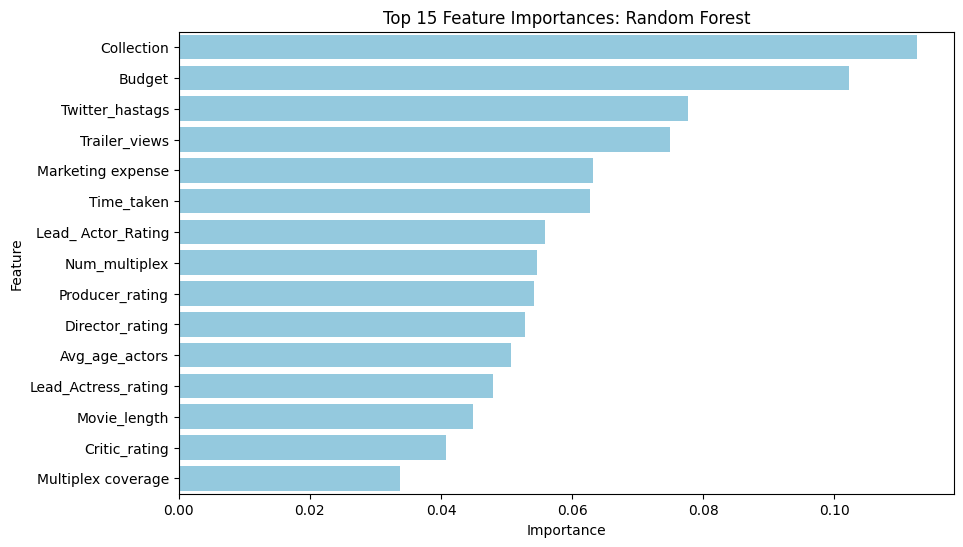

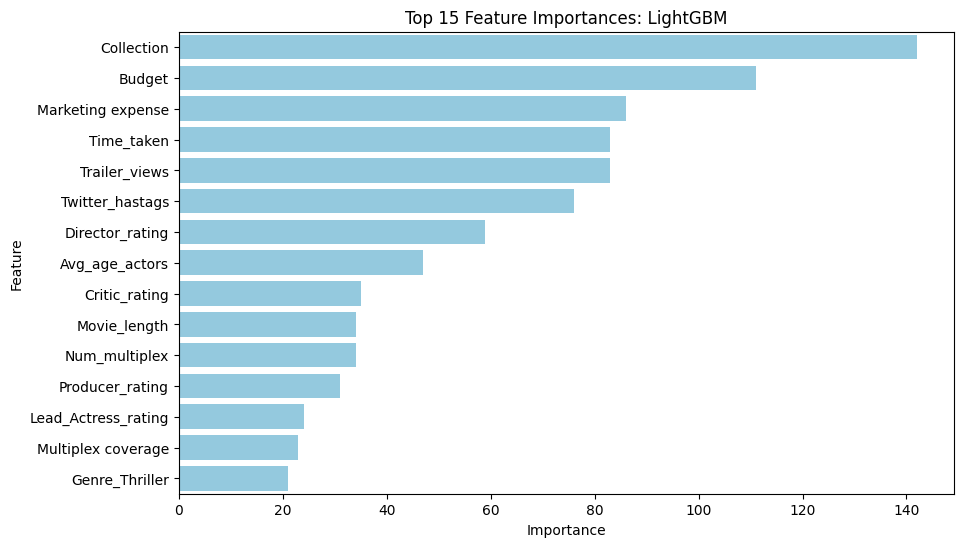

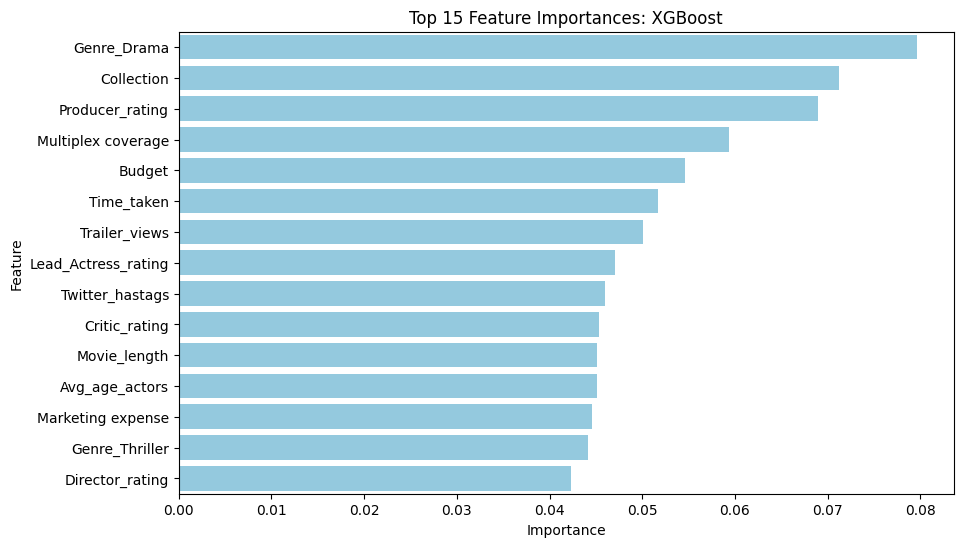

In [12]:
# Feature Importance

# Function to extract feature names from preprocessor
def get_feature_names(preprocessor, numeric_features, categorical_features):
    transformers = preprocessor.named_transformers_
    # OneHotEncoding feature names
    cat_features = transformers['cat'].get_feature_names_out(categorical_features)
    # Combine back
    all_features = numeric_features + list(cat_features)
    return all_features

feature_names = get_feature_names(preprocessor, numeric_features, categorical_features)

def plot_importance(model, name):
    # Extract classifier from pipeline
    clf = model.named_steps['clf']
    
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    else:
        return
        
    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_df, color='skyblue')
    plt.title(f'Top 15 Feature Importances: {name}')
    plt.show()

plot_importance(rf_champion, "Random Forest")
plot_importance(lgb_champion, "LightGBM")
plot_importance(xgb_champion, "XGBoost") 